<a href="https://colab.research.google.com/github/void-coder-x/DABA_SIG/blob/main/PS2_Network_Anomaly_Clustering_RAG_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 🤖 PS2 – Network Anomaly Clustering & MITRE ATT&CK RAG Workflow

### SIG-DABA – Security Analytics Project

**Problem Statement:**
Develop network-anomaly clustering and define the MITRE ATT&CK RAG workflow.

---

## Objective

The objective of PS2 is to develop the network-anomaly clustering component in greater detail and define how detected anomalies can flow into a MITRE ATT&CK Retrieval-Augmented Generation (RAG) workflow.

The PS2 implementation focuses on:

- Preparing network traffic features for clustering.
- Applying unsupervised clustering.
- Investigating different cluster configurations.
- Selecting an initial clustering configuration.
- Calculating anomaly scores.
- Identifying suspicious network flows.
- Defining the workflow from detected anomalies to MITRE ATT&CK retrieval.
- Establishing the foundation for detailed ATT&CK mapping in PS3.

---

## PS2 Workflow

```text
Network Traffic
      ↓
Data Preprocessing
      ↓
Feature Selection
      ↓
Feature Scaling
      ↓
Cluster Analysis
      ↓
K-Means Clustering
      ↓
Cluster Assignment
      ↓
Anomaly Score
      ↓
Suspicious Flow
      ↓
Behavior Representation
      ↓
MITRE ATT&CK RAG Workflow

In [ ]:

# CELL 2 — Markdown

```markdown
## 📌 PS2 Scope

PS2 focuses specifically on:

### Part A – Network Anomaly Clustering

```text
Network Flow
     ↓
Feature Preparation
     ↓
Scaling
     ↓
K-Means
     ↓
Clusters
     ↓
Anomaly Score

In [ ]:

# CELL 3 — Markdown
## 🧠 Why Unsupervised Clustering?

Network datasets can contain large amounts of traffic where previously unseen or insufficiently labeled behaviors may occur.

Unsupervised clustering groups network flows according to their feature similarity without requiring attack labels during model training.

In this PS2 prototype, K-Means clustering is used to identify groups of similar network behavior.

The original attack labels are retained only for post-clustering evaluation.

In [1]:
# ============================================
# PS2 - Environment Setup
# ============================================

!pip -q install pandas numpy scikit-learn matplotlib seaborn requests faiss-cpu transformers

import os
import json
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("PS2 environment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 54.9 MB/s eta 0:00:00
PS2 environment ready.


In [ ]:
# 📊 Dataset

The PS2 implementation uses the CICIDS2017 network traffic dataset.

The dataset contains flow-level network features such as:

- Flow duration
- Packet statistics
- Byte statistics
- Forward/backward traffic
- Network protocol information
- TCP-related features
- Flow rates
- Traffic labels

The `Label` column is **not used during clustering**.

In [2]:
# ============================================
# Upload Dataset
# ============================================

from google.colab import files

uploaded = files.upload()

csv_files = [
    name for name in uploaded.keys()
    if name.lower().endswith(".csv")
]

if not csv_files:
    raise FileNotFoundError(
        "Please upload the CICIDS2017 CSV file."
    )

DATASET_PATH = csv_files[0]

print("Dataset:", DATASET_PATH)

Saving Friday-WorkingHours-Morning.pcap_ISCX.csv to Friday-WorkingHours-Morning.pcap_ISCX.csv
Dataset: Friday-WorkingHours-Morning.pcap_ISCX.csv


In [3]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_csv(DATASET_PATH)

df.columns = df.columns.str.strip()

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (191033, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [4]:
# ============================================
# Label Analysis
# ============================================

print("Number of labels:", df["Label"].nunique())

display(
    df["Label"]
    .value_counts()
    .to_frame("Count")
)

Number of labels: 2


,Count
Label,
BENIGN,189067
Bot,1966


In [ ]:
# 🧹 Data Preprocessing

The preprocessing pipeline removes data-quality problems before clustering.

Steps:

1. Remove unnecessary whitespace.
2. Separate labels from features.
3. Convert features to numeric values.
4. Replace infinite values.
5. Remove invalid rows.
6. Remove duplicate features.
7. Remove constant features.
8. Prepare the final numerical feature matrix.

In [5]:
# ============================================
# Separate Features and Labels
# ============================================

labels = df["Label"].astype(str).str.strip()

X = df.drop(columns=["Label"]).copy()

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Initial feature count:", X.shape[1])

Initial feature count: 78


In [6]:
# ============================================
# Clean Invalid Values
# ============================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

valid_rows = ~X.isna().any(axis=1)

X = X.loc[valid_rows].reset_index(drop=True)
y = labels.loc[valid_rows].reset_index(drop=True)

print("Rows after cleaning:", len(X))
print("Remaining features:", X.shape[1])

Rows after cleaning: 190911
Remaining features: 78


In [7]:
# ============================================
# Remove Duplicate Columns
# ============================================

duplicate_mask = X.T.duplicated()

duplicate_columns = X.columns[
    duplicate_mask
].tolist()

X = X.loc[:, ~duplicate_mask]

print(
    "Duplicate columns removed:",
    len(duplicate_columns)
)

print(
    "Features remaining:",
    X.shape[1]
)

Duplicate columns removed: 16
Features remaining: 62


In [8]:
# ============================================
# Remove Constant Features
# ============================================

constant_columns = [
    column
    for column in X.columns
    if X[column].nunique() <= 1
]

X = X.drop(
    columns=constant_columns
)

print(
    "Constant columns removed:",
    len(constant_columns)
)

print(
    "Final feature count:",
    X.shape[1]
)

Constant columns removed: 1
Final feature count: 61


In [ ]:
# 🔍 Feature Analysis

Before clustering, the numerical features are examined to understand their scale and variability.

Network-flow features can have very different ranges.

For example:

```text
Packet Count       → relatively small values
Flow Duration      → potentially large values
Bytes Transferred  → potentially very large values
Flow Rate          → different numerical scale

In [9]:
# CELL 15 — Code

### Feature Statistics
# ============================================
# Feature Statistics
# ============================================

feature_stats = X.describe().T

display(
    feature_stats[
        ["mean", "std", "min", "max"]
    ].head(20)
)

,mean,std,min,max
Destination Port,6.746487e+03,1.668799e+04,0.0,6.494800e+04
Flow Duration,1.165243e+07,3.070924e+07,-12.0,1.200000e+08
Total Fwd Packets,1.383442e+01,1.098106e+03,1.0,2.079640e+05
Total Backward Packets,1.642389e+01,1.480265e+03,0.0,2.846020e+05
Total Length of Fwd Packets,6.003206e+02,7.926716e+03,0.0,1.235152e+06
Total Length of Bwd Packets,2.840378e+04,3.315597e+06,0.0,6.270000e+08
Fwd Packet Length Max,1.748190e+02,5.546355e+02,0.0,2.482000e+04
Fwd Packet Length Min,2.391025e+01,4.192031e+01,0.0,2.325000e+03
Fwd Packet Length Mean,5.190502e+01,1.170620e+02,0.0,5.940857e+03
Fwd Packet Length Std,5.022203e+01,1.604988e+02,0.0,7.049469e+03


In [10]:
# ============================================
# Feature Standard Deviation
# ============================================

feature_std = X.std().sort_values(
    ascending=False
)

display(
    feature_std.head(15).to_frame(
        "Standard Deviation"
    )
)

,Standard Deviation
Flow Duration,3.070924e+07
Fwd IAT Total,3.057837e+07
Bwd IAT Total,2.961278e+07
Flow Bytes/s,2.464050e+07
Flow IAT Max,1.473462e+07
Fwd IAT Max,1.467659e+07
Idle Max,1.424541e+07
Idle Mean,1.388675e+07
Idle Min,1.370882e+07
Bwd IAT Max,1.359483e+07


In [ ]:
# 📏 Feature Scaling

K-Means uses distance calculations.

Therefore, the network features are standardized using `StandardScaler`.

The transformation produces features approximately centered around zero with unit variance.

```text
Raw Features
     ↓
StandardScaler
     ↓
Scaled Feature Matrix
     ↓
K-Means

In [11]:

# CELL 18 — Code
# ============================================
# Standardize Features
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(
    "Scaled matrix shape:",
    X_scaled.shape
)

Scaled matrix shape: (190911, 61)


In [ ]:
# 📐 Selecting the Number of Clusters

K-Means requires the number of clusters to be specified.

To investigate suitable values, the prototype evaluates multiple values of `K`.

Two measures are considered:

- **Inertia** – within-cluster sum of squared distances.
- **Silhouette Score** – measures how well-separated the resulting clusters are.

These measurements provide evidence for selecting an initial clustering configuration.

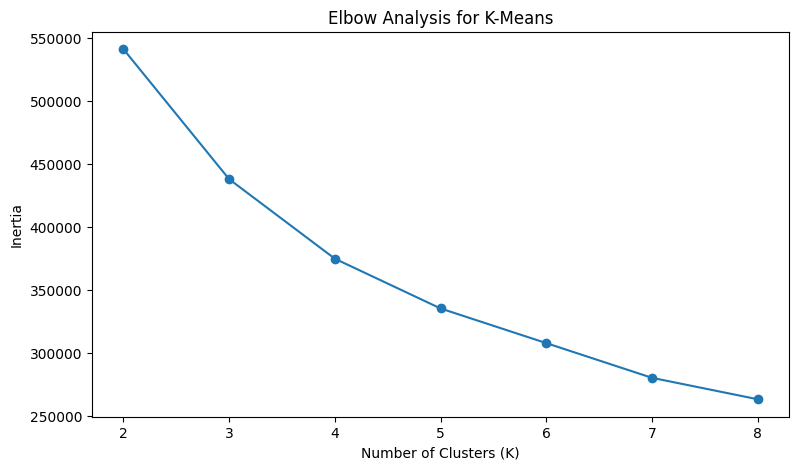

In [12]:
# ============================================
# Elbow Analysis
# ============================================

# Use a sample to reduce computation time
sample_size = min(10000, len(X_scaled))

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

k_values = range(2, 9)

inertias = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_sample)

    inertias.append(
        model.inertia_
    )

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Analysis for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))

plt.show()

In [13]:
# ============================================
# Silhouette Analysis
# ============================================

silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_sample = model.fit_predict(
        X_sample
    )

    score = silhouette_score(
        X_sample,
        labels_sample
    )

    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": list(k_values),
    "Silhouette_Score": silhouette_scores
})

display(silhouette_results)

,K,Silhouette_Score
0,2,0.984191
1,3,0.490323
2,4,0.468463
3,5,0.466569
4,6,0.316682
5,7,0.329339
6,8,0.343030


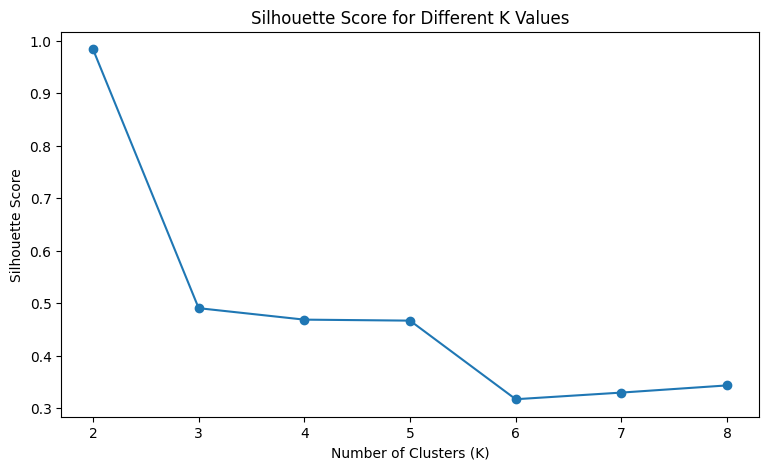

In [14]:
# ============================================
# Silhouette Score Plot
# ============================================

plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.show()

In [ ]:
# 🎯 Initial Cluster Selection

For the PS2 prototype, the clustering configuration is selected using the observed clustering diagnostics.

If the elbow does not produce a clear single choice, the final selection should be treated as an experimental configuration rather than a mathematically unique optimum.

For consistency with the PS1 prototype, `K = 4` is used as the initial clustering configuration.

In [15]:
# ============================================
# Final K-Means Model
# ============================================

N_CLUSTERS = 4

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

print("K-Means completed.")
print("Number of clusters:", N_CLUSTERS)

K-Means completed.
Number of clusters: 4


,Number of Flows
0,33923
1,152619
2,6
3,4363


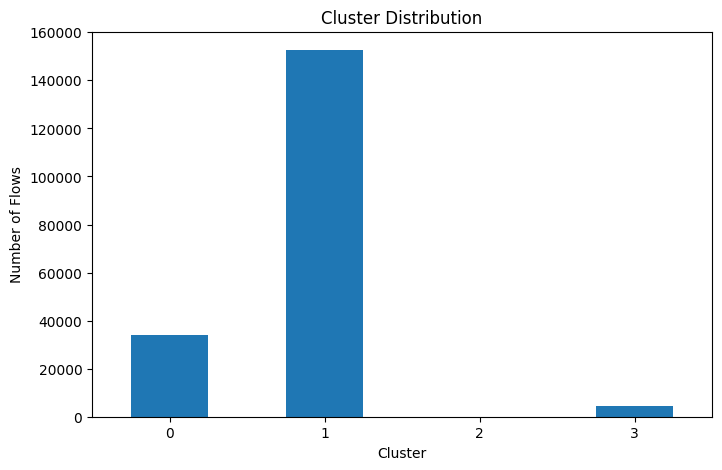

In [20]:
# ============================================
# Cluster Distribution
# ============================================

cluster_distribution = (
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

display(
    cluster_distribution.to_frame(
        "Number of Flows"
    )
)

plt.figure(figsize=(8, 5))

cluster_distribution.plot(
    kind="bar"
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Flows")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# 🔬 Cluster Quality

Two internal clustering measures are calculated:

### Silhouette Score

Measures how similar a flow is to its own cluster compared with other clusters.

Higher values generally indicate better-separated clusters.

### Davies-Bouldin Index

Measures cluster similarity based on within-cluster scatter and between-cluster separation.

Lower values generally indicate better separation.

In [22]:
# ============================================
# Cluster Quality Metrics
# ============================================

silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

davies_bouldin = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

Silhouette Score: 0.4781
Davies-Bouldin Index: 0.9510


In [ ]:
# 🚨 Anomaly Detection

K-Means itself is a clustering algorithm rather than a dedicated anomaly detector.

For this PS2 implementation, an anomaly score is derived from the distance between each flow and the centroid of its assigned cluster.

```text
Network Flow
      ↓
Assigned Cluster
      ↓
Cluster Centroid
      ↓
Distance
      ↓
Anomaly Score

In [23]:

# CELL 29 — Code
# ============================================
# Calculate Anomaly Scores
# ============================================

cluster_centers = kmeans.cluster_centers_

anomaly_scores = np.linalg.norm(
    X_scaled -
    cluster_centers[cluster_labels],
    axis=1
)

results = X.copy()

results["Label"] = y
results["Cluster"] = cluster_labels
results["Anomaly_Score"] = anomaly_scores

display(
    results[
        [
            "Label",
            "Cluster",
            "Anomaly_Score"
        ]
    ].head()
)

,Label,Cluster,Anomaly_Score
0,BENIGN,0,8.922197
1,BENIGN,0,9.269225
2,BENIGN,0,24.127621
3,BENIGN,1,2.300282
4,BENIGN,1,4.763205


In [ ]:
# 🎯 Anomaly Threshold

A percentile-based threshold is used to convert the continuous anomaly score into a binary anomaly flag.

For PS2, multiple percentiles are compared:

- 90th percentile
- 92nd percentile
- 95th percentile
- 97th percentile
- 98th percentile
- 99th percentile

This allows the effect of the threshold on the number of detected anomalies to be observed.

In [24]:
# ============================================
# Compare Anomaly Thresholds
# ============================================

percentiles = [
    90,
    92,
    95,
    97,
    98,
    99
]

threshold_results = []

for percentile in percentiles:

    threshold_value = np.percentile(
        results["Anomaly_Score"],
        percentile
    )

    anomaly_count = (
        results["Anomaly_Score"] >
        threshold_value
    ).sum()

    anomaly_percentage = (
        anomaly_count /
        len(results)
    ) * 100

    threshold_results.append({
        "Percentile": percentile,
        "Threshold": threshold_value,
        "Anomaly_Count": anomaly_count,
        "Anomaly_Percentage": anomaly_percentage
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Percentile,Threshold,Anomaly_Count,Anomaly_Percentage
0,90,7.788567,19091,9.999948
1,92,8.677925,15273,8.000063
2,95,10.894147,9546,5.000236
3,97,13.170554,5728,3.000351
4,98,14.800694,3819,2.000409
5,99,18.453480,1910,1.000466


In [ ]:
## Threshold Selection

For consistency with the initial PS1 prototype, the **95th percentile** is used as the working threshold.

The threshold is a prototype parameter and should be validated further using security-specific evaluation and analyst review.

In [25]:
# ============================================
# Apply 95th Percentile Threshold
# ============================================

ANOMALY_PERCENTILE = 95

threshold = np.percentile(
    results["Anomaly_Score"],
    ANOMALY_PERCENTILE
)

results["Predicted_Anomaly"] = (
    results["Anomaly_Score"] >
    threshold
).astype(int)

print(
    "Threshold:",
    threshold
)

print(
    "Detected anomalies:",
    results["Predicted_Anomaly"].sum()
)

print(
    "Anomaly percentage:",
    f"{results['Predicted_Anomaly'].mean() * 100:.2f}%"
)

Threshold: 10.894147262766612
Detected anomalies: 9546
Anomaly percentage: 5.00%


In [26]:
# ============================================
# Top Anomalies
# ============================================

top_anomalies = results.sort_values(
    "Anomaly_Score",
    ascending=False
).head(20)

display(
    top_anomalies[
        [
            "Label",
            "Cluster",
            "Anomaly_Score",
            "Predicted_Anomaly"
        ]
    ]
)

,Label,Cluster,Anomaly_Score,Predicted_Anomaly
18338,BENIGN,0,212.200790,1
93666,BENIGN,0,200.996838,1
56587,BENIGN,0,198.767145,1
117753,BENIGN,0,163.803763,1
117780,BENIGN,0,158.146933,1
69593,BENIGN,0,152.579626,1
84744,BENIGN,0,138.276144,1
72329,BENIGN,0,137.887427,1
114693,BENIGN,0,125.936221,1
115553,BENIGN,0,125.077515,1


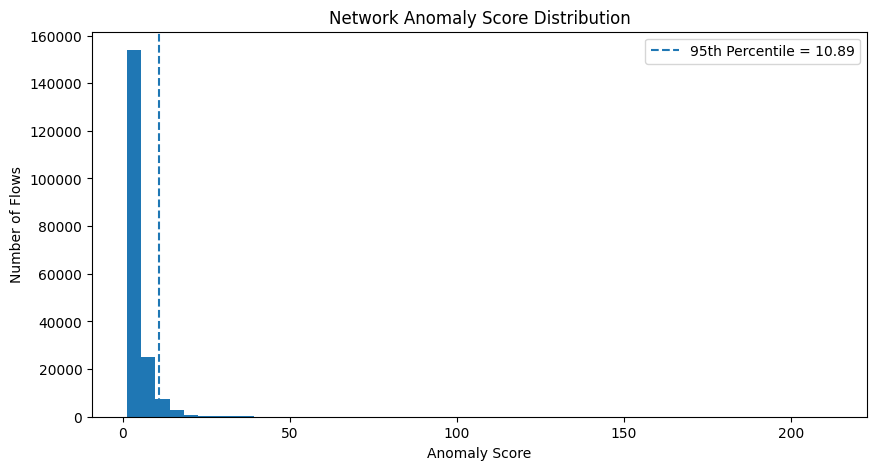

In [27]:
# ============================================
# Anomaly Score Distribution
# ============================================

plt.figure(figsize=(10, 5))

plt.hist(
    results["Anomaly_Score"],
    bins=50
)

plt.axvline(
    threshold,
    linestyle="--",
    label=f"95th Percentile = {threshold:.2f}"
)

plt.title(
    "Network Anomaly Score Distribution"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Flows")

plt.legend()

plt.show()

In [ ]:
# 🔗 MITRE ATT&CK RAG Workflow

PS2 defines how the anomaly detection component connects to the MITRE ATT&CK RAG pipeline.

The workflow is:

```text
Detected Network Anomaly
          ↓
Feature / Behavior Analysis
          ↓
Human-Readable Behavior Representation
          ↓
Security Query
          ↓
Query Embedding
          ↓
Vector Similarity Search
          ↓
MITRE ATT&CK Documents
          ↓
Retrieved Context
          ↓
RAG Pipeline
          ↓
Security Analysis

In [ ]:

---

# CELL 37 — Markdown

```markdown
# 🧩 RAG Workflow Components

### 1. Anomaly Detection

The clustering model identifies unusual network flows.

### 2. Behavior Representation

Relevant network characteristics are transformed into a meaningful security description.

### 3. Query Formation

The description is used to formulate a semantic retrieval query.

### 4. Embedding

The query is converted into a vector representation.

### 5. Retrieval

The query vector is compared against indexed MITRE ATT&CK documents.

### 6. Context Construction

The highest-relevance documents are selected as context.

### 7. Generation

An LLM can use the retrieved context to produce security analysis.

### 8. Evidence

The assistant should expose the retrieved ATT&CK information supporting its response.

In [ ]:
## 🔄 PS2 End-to-End Architecture

```text
┌─────────────────────────────┐
│   Network Traffic Logs      │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Data Preprocessing        │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Feature Scaling           │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   K-Means Clustering        │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Anomaly Score             │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Suspicious Flow           │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Behavior Representation   │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Query Embedding           │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   MITRE ATT&CK Retrieval    │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   Retrieved Context         │
└──────────────┬──────────────┘
               ↓
┌─────────────────────────────┐
│   RAG / LLM Analysis        │
└─────────────────────────────┘

In [28]:

# CELL 39 — Code

### Create PS2 RAG Workflow Example

#This cell **defines** the workflow without prematurely implementing PS3/PS4/PS5.

# ============================================
# PS2 - RAG Workflow Definition
# ============================================

rag_workflow = {
    "stage_1": "Network traffic input",
    "stage_2": "Data preprocessing",
    "stage_3": "Feature scaling",
    "stage_4": "Unsupervised clustering",
    "stage_5": "Anomaly score calculation",
    "stage_6": "Suspicious flow identification",
    "stage_7": "Behavior representation",
    "stage_8": "Query embedding",
    "stage_9": "MITRE ATT&CK similarity retrieval",
    "stage_10": "Retrieved context construction",
    "stage_11": "RAG / LLM security analysis"
}

for stage, description in rag_workflow.items():
    print(f"{stage}: {description}")

stage_1: Network traffic input
stage_2: Data preprocessing
stage_3: Feature scaling
stage_4: Unsupervised clustering
stage_5: Anomaly score calculation
stage_6: Suspicious flow identification
stage_7: Behavior representation
stage_8: Query embedding
stage_9: MITRE ATT&CK similarity retrieval
stage_10: Retrieved context construction
stage_11: RAG / LLM security analysis


In [ ]:
# 📌 Important PS2 Boundary

PS2 establishes the clustering and RAG workflow.

It does **not** perform the detailed work assigned to later problem statements.

| Component | PS |
|---|---|
| Network anomaly clustering | **PS2** |
| RAG workflow definition | **PS2** |
| Anomaly → ATT&CK technique mapping | PS3 |
| MITRE ATT&CK knowledge-base construction | PS4 |
| Detailed prompt design | PS5 |
| Working RAG assistant | PS6 |
| Testing | PS7 |
| Evaluation | PS8 |

In [29]:
# ============================================
# Save PS2 Results
# ============================================

os.makedirs(
    "ps2_results",
    exist_ok=True
)

# Save threshold comparison
threshold_df.to_csv(
    "ps2_results/threshold_comparison.csv",
    index=False
)

# Save top anomalies
top_anomalies.to_csv(
    "ps2_results/top_anomalies.csv",
    index=False
)

# Save clustering summary
cluster_summary = pd.DataFrame({
    "Cluster": cluster_distribution.index,
    "Number_of_Flows": cluster_distribution.values
})

cluster_summary.to_csv(
    "ps2_results/cluster_summary.csv",
    index=False
)

# Save PS2 summary
ps2_summary = {
    "dataset_rows": int(len(df)),
    "cleaned_rows": int(len(X)),
    "features": int(X.shape[1]),
    "clusters": int(N_CLUSTERS),
    "silhouette_score": float(silhouette),
    "davies_bouldin_index": float(davies_bouldin),
    "anomaly_percentile": int(ANOMALY_PERCENTILE),
    "anomaly_threshold": float(threshold),
    "detected_anomalies": int(
        results["Predicted_Anomaly"].sum()
    )
}

with open(
    "ps2_results/ps2_summary.json",
    "w"
) as f:
    json.dump(
        ps2_summary,
        f,
        indent=2
    )

print("PS2 results saved.")

PS2 results saved.


In [30]:
# ============================================
# Download PS2 Results
# ============================================

!zip -qr PS2_results.zip ps2_results

from google.colab import files

files.download(
    "PS2_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 📊 PS2 Results

## Clustering

The network traffic was successfully preprocessed, standardized and grouped using K-Means clustering.

## Cluster Analysis

Multiple values of K were investigated using:

- Elbow analysis
- Silhouette Score

The PS2 prototype uses K = 4 consistently with the initial PS1 configuration.

## Anomaly Detection

Anomaly scores were calculated using the distance between each flow and its assigned cluster centroid.

A 95th-percentile threshold was used as the working prototype threshold.

## RAG Workflow

The PS2 workflow establishes the connection:

```text
Network Anomaly
      ↓
Behavior Representation
      ↓
Query
      ↓
Embedding
      ↓
MITRE ATT&CK Retrieval
      ↓
Retrieved Context
      ↓
RAG / LLM Analysis

In [ ]:

---

# CELL 44 — Markdown

### Limitations

```markdown
# ⚠️ Limitations

1. K-Means requires the number of clusters to be specified.
2. The selected K value is an experimental configuration.
3. Anomaly scores are based on distance from cluster centroids.
4. Percentile-based thresholds require further validation.
5. Clustering quality metrics do not directly measure cybersecurity usefulness.
6. Anomaly detection alone does not establish that a specific ATT&CK technique occurred.
7. The detailed anomaly-to-ATT&CK mapping is outside PS2.
8. The complete MITRE knowledge-base construction is outside PS2.
9. The complete LLM-powered RAG assistant is developed in later problem statements.

In [ ]:
# 🚀 Future Work

The PS2 results provide the foundation for:

- **PS3:** Connecting detected anomalies with relevant MITRE ATT&CK techniques.
- **PS4:** Building and indexing the MITRE ATT&CK knowledge base.
- **PS5:** Designing attack-identification and mitigation prompts.
- **PS6:** Developing the working security RAG assistant.
- **PS7–PS15:** Testing, evaluation, error analysis, improvement, interface development, integration and final demonstration.

In [ ]:
# ✅ Conclusion

PS2 developed the network-anomaly clustering component and defined the workflow connecting anomaly detection with a MITRE ATT&CK RAG pipeline.

The network traffic was cleaned and standardized before applying K-Means clustering. Multiple cluster configurations were investigated using clustering diagnostics, and anomaly scores were calculated from the distance between network flows and their assigned cluster centroids.

A complete conceptual RAG workflow was also established:

```text
Network Traffic
      ↓
Unsupervised Clustering
      ↓
Anomaly Detection
      ↓
Behavior Representation
      ↓
Query Embedding
      ↓
MITRE ATT&CK Retrieval
      ↓
Retrieved Context
      ↓
RAG / LLM Analysis